## Setup

In [1]:
from __future__ import annotations
from pathlib import Path
import glob
from collections import defaultdict

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

jax.config.update("jax_enable_x64", True)

# To match submission figures
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 8,
        "axes.labelsize": 8,
        "legend.fontsize": 7,
        "figure.dpi": 300,
    }
)

## Loss Landscape Analysis

In [14]:
plot_data = defaultdict(dict)
hessians = {}
# Get plot_data
for p in glob.glob("data/results_*"):
    name = Path(p).stem
    _, method, eta_part = name.split("_")
    eta = float(eta_part.split("=")[1])
    data = jnp.load(p)
    H = data["H"]
    alpha = data["alpha"]
    beta = data["beta"]
    Ls = data["Ls"]
    median_L = jnp.nanmedian(Ls, axis=1)

    N = int(jnp.sqrt(median_L.size))
    Z_plot = median_L.reshape(N, N)
    Z_log = jnp.log10(Z_plot)
    xi = jnp.linspace(alpha.min(), alpha.max(), N)
    yi = jnp.linspace(beta.min(), beta.max(), N)
    Xi, Yi = jnp.meshgrid(xi, yi)
    plot_data[method][eta] = (Xi, Yi, Z_log)
    if eta == 0.0:
        hessians[method] = H

### $\kappa(\mathbf{\bar H}_{\textrm{loss}})$ and $\lambda_i$ at the solution $K^*$

In [41]:
for m, H in hessians.items():
    evals = jnp.linalg.eigvalsh(H)
    cond_num = evals[-1] / evals[0]
    print(f"Condition Number ({m}): {cond_num}")
    print(f"Eigenvalues ({m}): {evals}")

Condition Number (node): 1.982253603322436e+22
Eigenvalues (node): [1.13362199e+29 5.66066349e+43 4.45754315e+46 2.24712627e+51]
Condition Number (hodel): 5.839401963403165e+18
Eigenvalues (hodel): [2.76089115e-09 1.16544315e+06 5.40106826e+06 1.61219532e+10]
Condition Number (deq): 3.5758882639465824e+16
Eigenvalues (deq): [5.16307484e-06 8.53311306e+06 3.16080478e+10 1.84625787e+11]
Condition Number (pinn): 1415708730900762.0
Eigenvalues (pinn): [1.79672300e+06 3.73723629e+16 5.28413649e+19 2.54363644e+21]


### 2D Contour

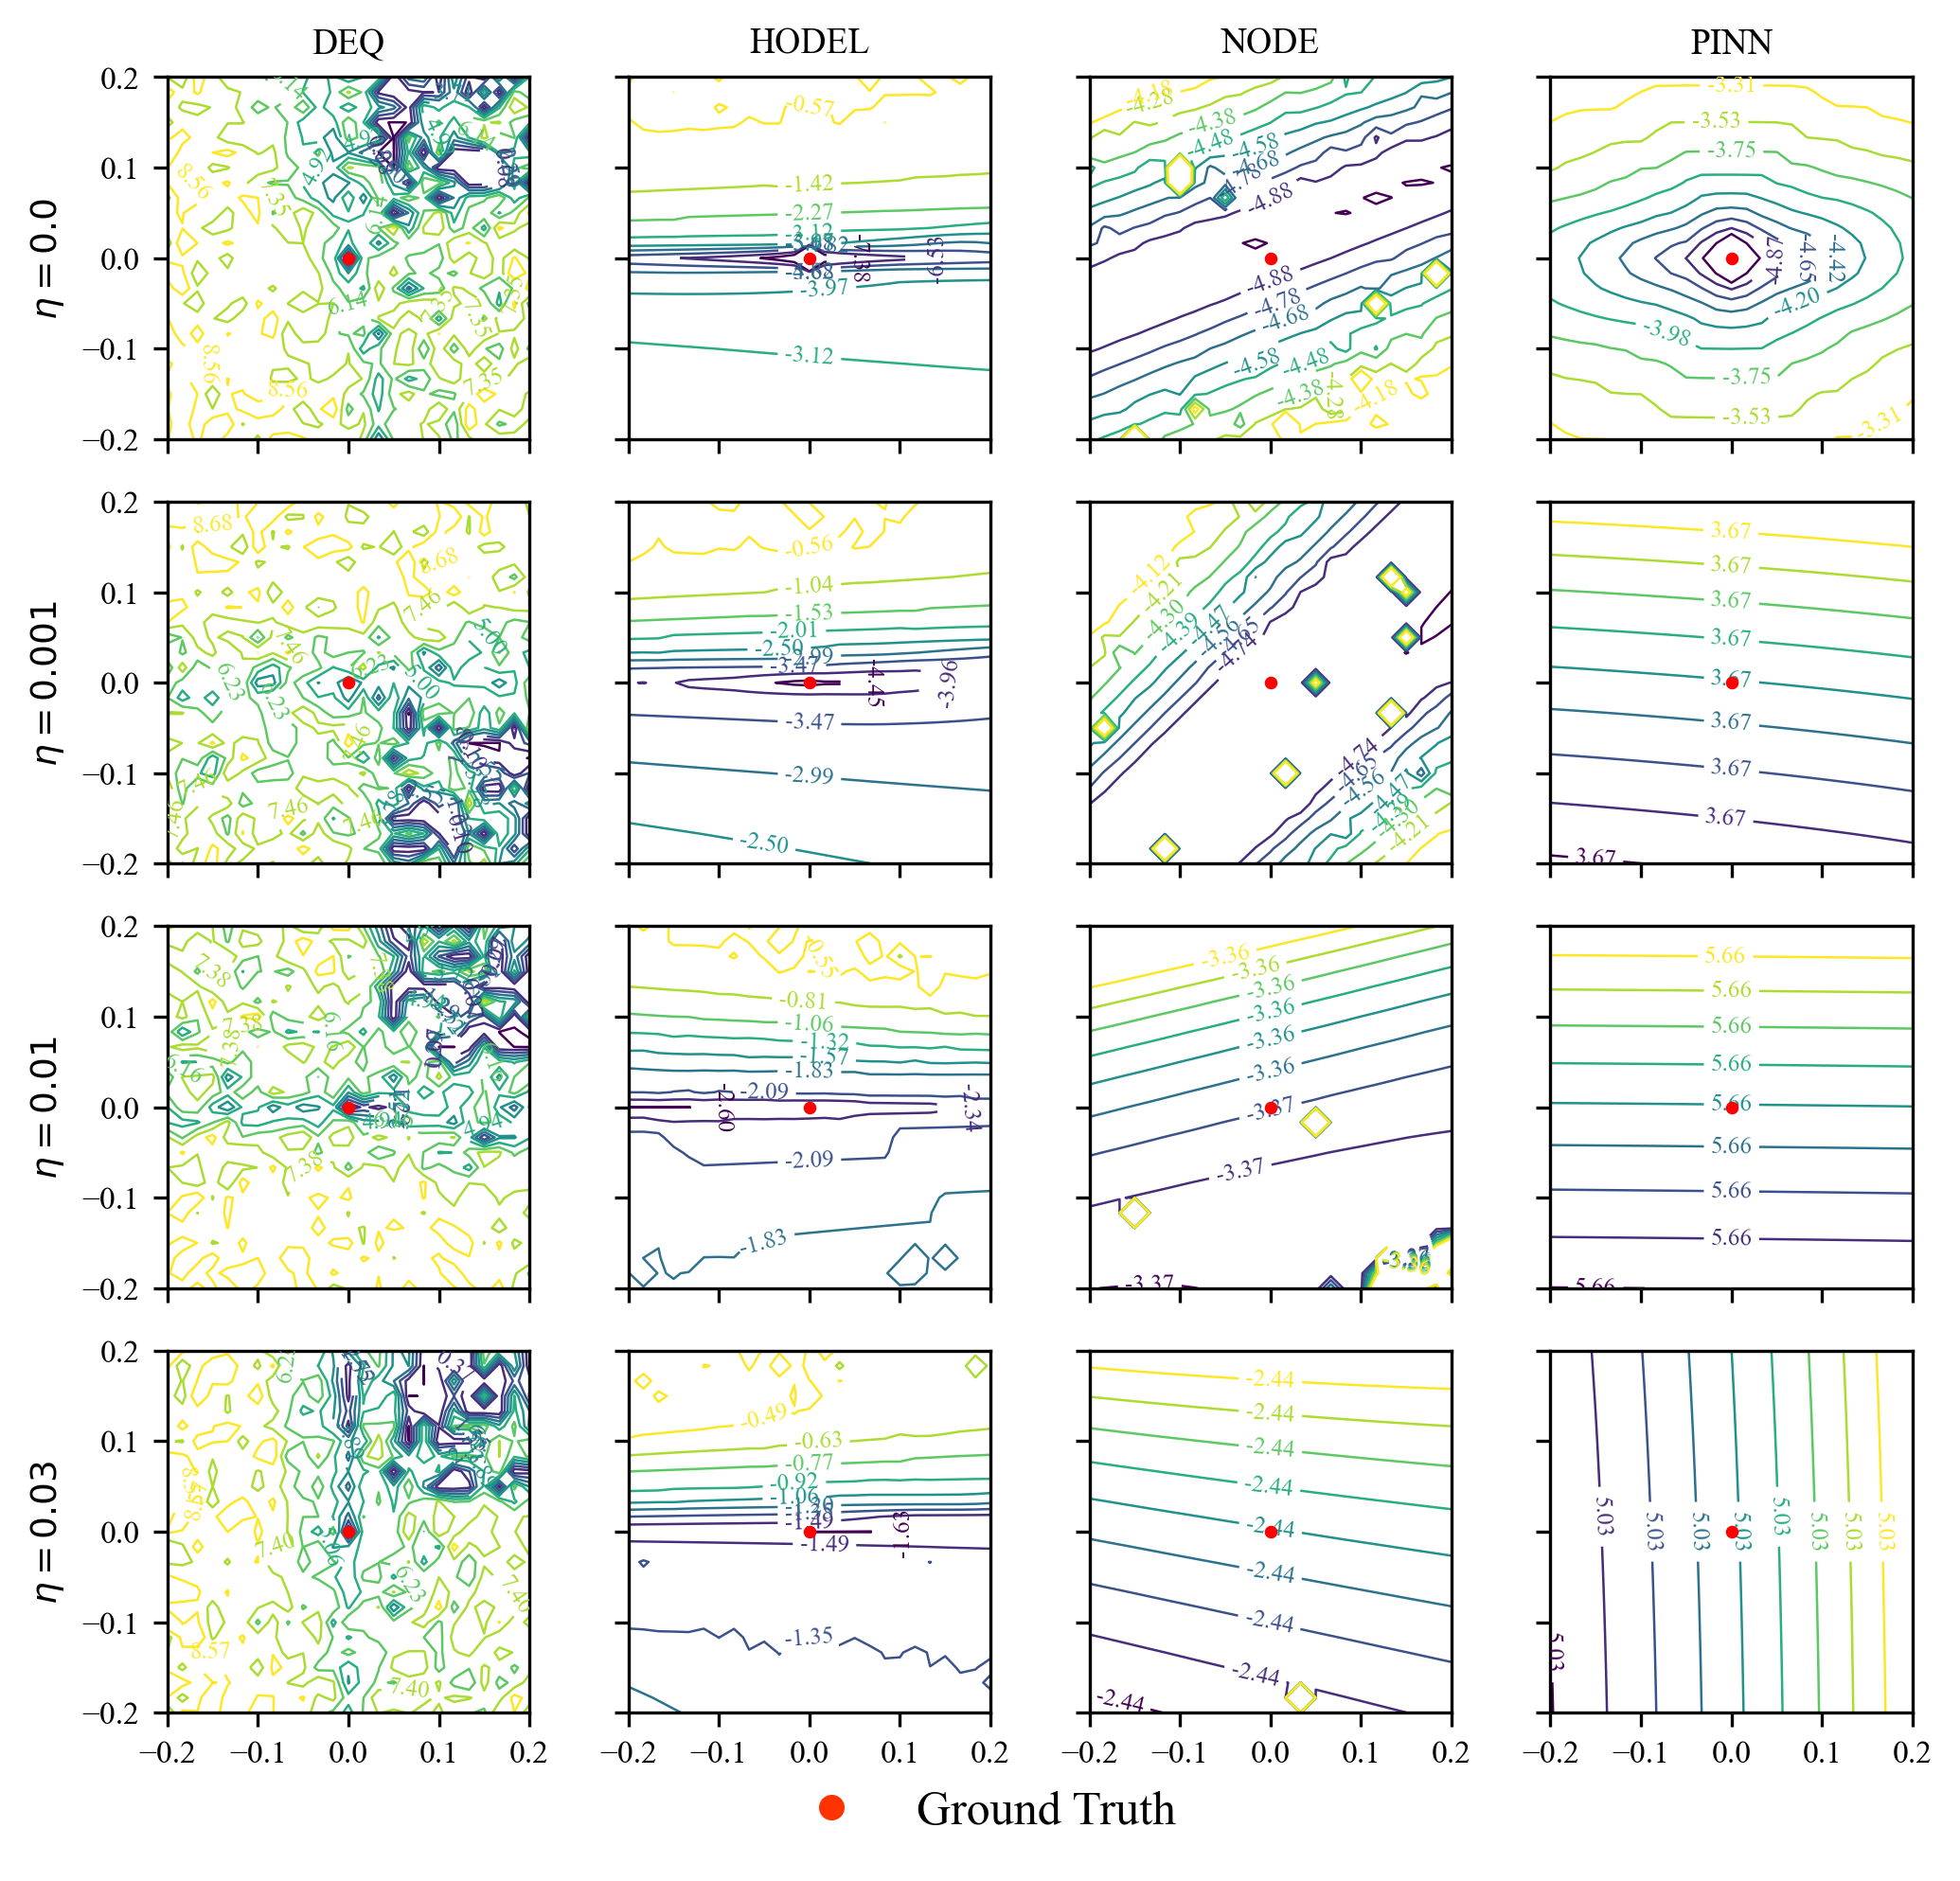

In [ ]:

methods = sorted(plot_data.keys())
etas = sorted(next(iter(plot_data.values())).keys())
fig, axes = plt.subplots(4, 4, figsize=(7, 6.5), sharex=True, sharey=True)

for i, eta in enumerate(etas):
    for j, method in enumerate(methods):
        ax = axes[i, j]
        Xi, Yi, Z_log = plot_data[method][eta]
        
        z_finite_local = Z_log[jnp.isfinite(Z_log)]
        v_min_local = float(jnp.nanpercentile(z_finite_local, 1))
        v_max_local = float(jnp.nanpercentile(z_finite_local, 90))
        local_levels = jnp.linspace(v_min_local, v_max_local, 17)

        # Swapped axis
        CS = ax.contour(
            Yi, 
            Xi, 
            Z_log,
            levels=local_levels[::2],
            cmap="viridis",
            linewidths=0.6,
            zorder=2,
        )
        
        ax.clabel(CS, inline=True, fontsize=6, fmt="%1.2f")
        ax.scatter(0, 0, color="red", marker=".", s=20, zorder=10)  # center marker
        ax.set_aspect('equal', 'box') 
        ax.set_xlim(-0.2, 0.2)
        ax.set_ylim(-0.2, 0.2)
        ax.set_xticks([-0.2, -0.1, 0, 0.1, 0.2])
        ax.set_yticks([-0.2, -0.1, 0, 0.1, 0.2])
        
        if i == 0:
            ax.set_title(method.upper(), fontsize=9)
        if j == 0:
            ax.set_ylabel(rf"$\eta={eta}$", fontsize=9)

# Fix the Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker=".",
        color="w",
        label="Ground Truth",
        markerfacecolor="#FF3300",
        markersize=15,
        markeredgecolor="white",
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=1,
    frameon=False,
    fontsize=12,
)

plt.tight_layout(rect=(0, 0.02, 1, 1))
#plt.savefig("3d_rod_loss_contours.pdf")
plt.show()

## Loss vs $\eta$

In [8]:
import glob
from pathlib import Path
import jax.numpy as jnp

results = []

for p in glob.glob("data/benchmarks_*"):
    name = Path(p).stem
    _, method, eta_part = name.split("_")
    eta = float(eta_part.split("=")[1])
    
    data = jnp.load(p)
    Ls = data["test_errors"]
    median_L = jnp.nanmedian(Ls, axis=0)
    std_L = jnp.nanstd(Ls, axis=0)
    results.append({
        "method": method,
        "eta": eta,
        "median": median_L[-1],
        "std": std_L[-1]
    })

results.sort(key=lambda x: (x["method"], x["eta"]))
for r in results:
    print(f"{r['method']} (eta={r['eta']}): {r['median']:.6f}±{r['std']:.6f}")

deq (eta=0.001): 0.001472±0.016613
deq (eta=0.01): 0.004348±0.051078
deq (eta=0.03): 0.006414±0.021485
hodel (eta=0.001): 0.000911±0.000284
hodel (eta=0.01): 0.000924±0.000334
hodel (eta=0.03): 0.000954±0.000415
node (eta=0.001): 0.027717±0.587088
node (eta=0.01): 0.032476±0.680224
node (eta=0.03): 0.035826±0.577593
pinn (eta=0.001): 0.014567±0.013823
pinn (eta=0.01): 0.090385±0.023056
pinn (eta=0.03): 0.031499±0.376398
